xxxx

In [91]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split,DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [63]:

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [64]:
os.makedirs("models",exist_ok=True)
os.makedirs("outputs",exist_ok=True)

In [65]:
BATCH_SIZE=64
EPOCHS=5
LEARNING_RATE=0.001

In [66]:
#Load temporarily for statistics

dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

loader = DataLoader(dataset, batch_size=60000)

data, _ = next(iter(loader))

mean = data.mean()
std = data.std()

print(mean, std)

tensor(0.1307) tensor(0.3081)


In [67]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

In [68]:
dataset=datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_data=datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

In [69]:
print(f"Len of train dataset {len(dataset)}")
print(f"Len of test dataset {len(test_data)}")


Len of train dataset 60000
Len of test dataset 10000


In [70]:
train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(
    dataset,
    [train_size,val_size]
)

In [71]:
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
    
)

test_loader=DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [72]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN,self).__init__()

        self.conv1=nn.Conv2d(
            in_channels=1,
            out_channels=32,
            padding=1,
            kernel_size=3
        )

        self.conv2=nn.Conv2d(
            in_channels=32,
            out_channels=64,
            padding=1,
            kernel_size=3
        )

        self.relu=nn.ReLU()
        self.pool=nn.MaxPool2d(kernel_size=2)

        self.fc1=nn.Linear(64*7*7,128)
        self.fc2=nn.Linear(128,10)

        self.dropout=nn.Dropout(0.25)

    def forward(self,x):

        x=self.conv1(x)
        x=self.relu(x)
        x=self.pool(x)

        x=self.conv2(x)
        x=self.relu(x)
        x=self.pool(x)

        x=x.view(x.size(0),-1)

        x=self.fc1(x)

        x=self.relu(x)
        x=self.dropout(x)

        x=self.fc2(x)

        return x





In [73]:
model=SimpleCNN().to(device=device)

In [74]:
criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(
    model.parameters(),
    LEARNING_RATE,

)

In [79]:
train_acc=[]
val_accuracies=[]

train_loss=[]
val_losses=[]

def calculate_accuracy(output,labels):
    _,predicted=torch.max(output,1)
    correct=(predicted==labels).sum().item()
    accuracy=correct/labels.size(0)
    return accuracy


In [86]:
for epoch in range(EPOCHS):
    model.train()

    running_loss=0
    running_acc=0

    for images,labels in train_loader:

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()
        running_acc+=calculate_accuracy(outputs,labels)
    
    epoch_train_loss=running_loss/len(train_loader)
    epoch_train_acc=running_acc/len(train_loader)

    train_loss.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)


    model.eval()

    val_loss=0
    val_acc=0

    with torch.no_grad():

        for images,labels in val_loader:
            
            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)
       
            loss=criterion(outputs,labels)

            val_loss+=loss.item()
            val_acc+=calculate_accuracy(outputs,labels)

    epoch_val_loss=val_loss/len(val_loader)
    epoch_val_acc=val_acc/len(val_loader)

    val_accuracies.append(epoch_val_acc)
    val_losses.append(epoch_val_loss)

    print(
        f"Epochs {epoch+1} | "
        f"Training loss {epoch_train_loss} | "
        f"Training Accuracy {epoch_train_acc} | "
        f"Validation Accuracy {epoch_val_acc} | "
        f"Validation Loss {epoch_val_loss} | "

    )

Epochs 1 | Training loss 0.015917189560328553 | Training Accuracy 0.9945 | Validation Accuracy 0.9896110372340425 | Validation Loss 0.03881871974422114 | 
Epochs 2 | Training loss 0.011317705775007805 | Training Accuracy 0.9960416666666667 | Validation Accuracy 0.9911901595744681 | Validation Loss 0.035046580808656996 | 
Epochs 3 | Training loss 0.009743576090282053 | Training Accuracy 0.9968333333333333 | Validation Accuracy 0.9891123670212766 | Validation Loss 0.041960000014288644 | 
Epochs 4 | Training loss 0.011443171345736119 | Training Accuracy 0.9960416666666667 | Validation Accuracy 0.9901097074468085 | Validation Loss 0.041650366852564354 | 
Epochs 5 | Training loss 0.008368100652525452 | Training Accuracy 0.9971041666666667 | Validation Accuracy 0.9891123670212766 | Validation Loss 0.049593895010981756 | 


In [109]:
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("outputs/training_curves.png")
plt.close()

In [90]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [92]:
print("\nClassification Report:\n")

print(classification_report(all_labels, all_preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Prediction visualization saved!


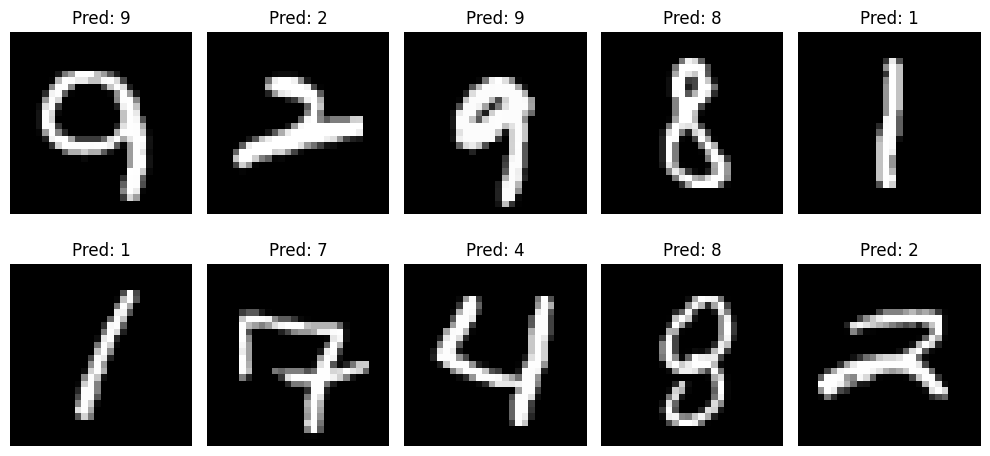

In [93]:
examples = iter(test_loader)
example_data, example_targets = next(examples)

example_data = example_data.to(device)

outputs = model(example_data)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    image = example_data[i].cpu().squeeze()

    plt.imshow(image, cmap="gray")

    plt.title(f"Pred: {preds[i].item()}")
    plt.axis("off")

plt.tight_layout()

plt.savefig("outputs/predictions.png")

print("Prediction visualization saved!")

In [96]:
torch.save(model.state_dict(),"models/cnn_model.pth")
print("model_saved")

model_saved


In [99]:
from PIL import Image
img=Image.open(r"C:\Users\aksha\OneDrive\Desktop\deep_learning\mnist_cnn_project\test_image\5.png")

In [112]:
from PIL import Image
import torch
from torchvision import transforms

model.eval()

img = Image.open(r"test_image\5.png")

img = img.convert("L")
img = img.resize((28,28))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

img = transform(img)

img = img.unsqueeze(0)

img = img.to(device)

with torch.no_grad():

    output = model(img)

    _, pred = torch.max(output,1)


print("Prediction:", pred.item())


Prediction: 5
